<a href="https://colab.research.google.com/github/Thorbiedee/EEG-alpha-brain-state-analysis-with-python/blob/main/EEG_alpha_brain_state_analysisv1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Tool installation

In [1]:
!pip install mne matplotlib numpy scipy

2. Library Importation

In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt

3. Loading dataset from Physionet
(https://physionet.org/content/eegmmidb/1.0.0/)

In [3]:
from mne.datasets import eegbci
from mne.io import concatenate_raws, read_raw_edf

In [4]:
subjects = [1]
runs = [1, 2]  # eyes open + eyes closed style data

files = eegbci.load_data(subjects[0], runs)

Using default location ~/mne_data for EEGBCI...
Creating /root/mne_data


Do you want to set the path:
    /root/mne_data
as the default EEGBCI dataset path in the mne-python config [y]/n? y
Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 29s (2.4 MB)


<RawEDF | S001R01.edf, 64 x 19520 (122.0 s), ~9.6 MiB, data loaded>
Using matplotlib as 2D backend.


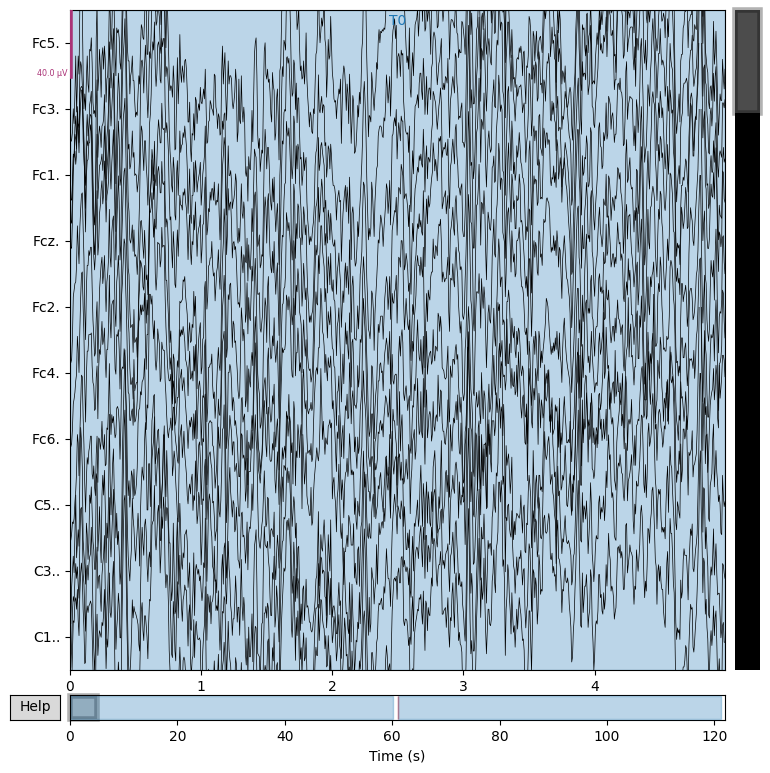

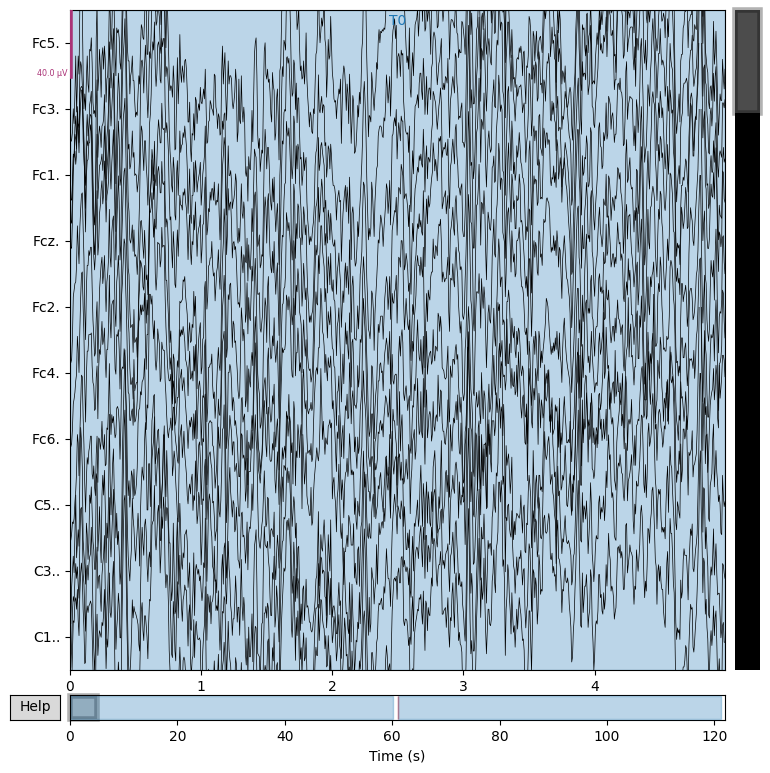

In [8]:
raws = [read_raw_edf(f, preload=True, verbose=False) for f in files]
raw = concatenate_raws(raws)
print(raw)
raw.plot(duration=5, n_channels=10)

STEP 4 — Understanding what EEG data actually is before analysis

In [9]:
print(raw.info)

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


In [10]:
raw.ch_names

['Fc5.',
 'Fc3.',
 'Fc1.',
 'Fcz.',
 'Fc2.',
 'Fc4.',
 'Fc6.',
 'C5..',
 'C3..',
 'C1..',
 'Cz..',
 'C2..',
 'C4..',
 'C6..',
 'Cp5.',
 'Cp3.',
 'Cp1.',
 'Cpz.',
 'Cp2.',
 'Cp4.',
 'Cp6.',
 'Fp1.',
 'Fpz.',
 'Fp2.',
 'Af7.',
 'Af3.',
 'Afz.',
 'Af4.',
 'Af8.',
 'F7..',
 'F5..',
 'F3..',
 'F1..',
 'Fz..',
 'F2..',
 'F4..',
 'F6..',
 'F8..',
 'Ft7.',
 'Ft8.',
 'T7..',
 'T8..',
 'T9..',
 'T10.',
 'Tp7.',
 'Tp8.',
 'P7..',
 'P5..',
 'P3..',
 'P1..',
 'Pz..',
 'P2..',
 'P4..',
 'P6..',
 'P8..',
 'Po7.',
 'Po3.',
 'Poz.',
 'Po4.',
 'Po8.',
 'O1..',
 'Oz..',
 'O2..',
 'Iz..']

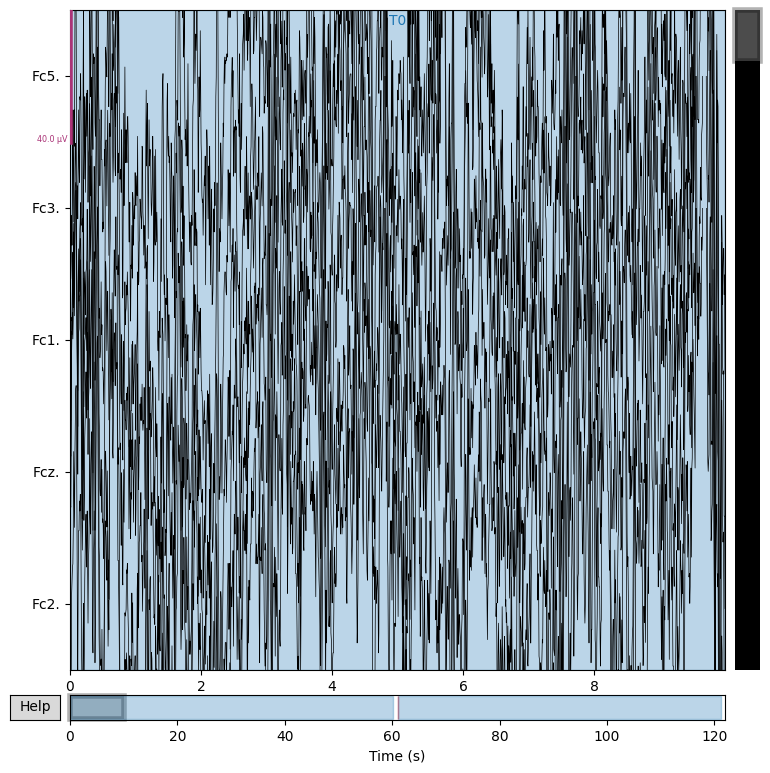

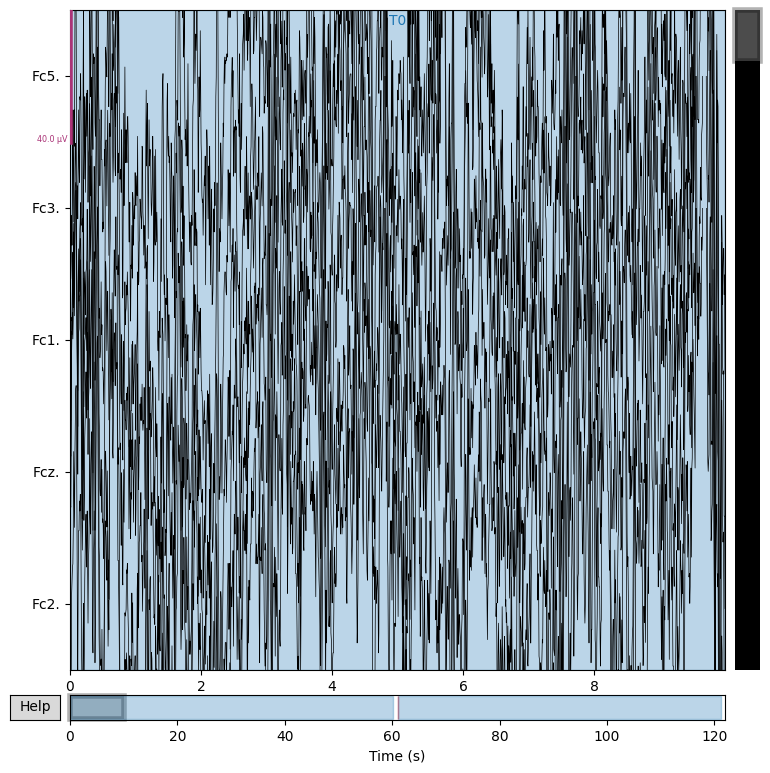

In [11]:
raw.plot(duration=10, n_channels=5)

5. Filtering the EEG Signal

In [12]:
raw_filtered = raw.copy().filter(l_freq=1.0, h_freq=40.0)

Filtering raw data in 2 contiguous segments
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 529 samples (3.306 s)



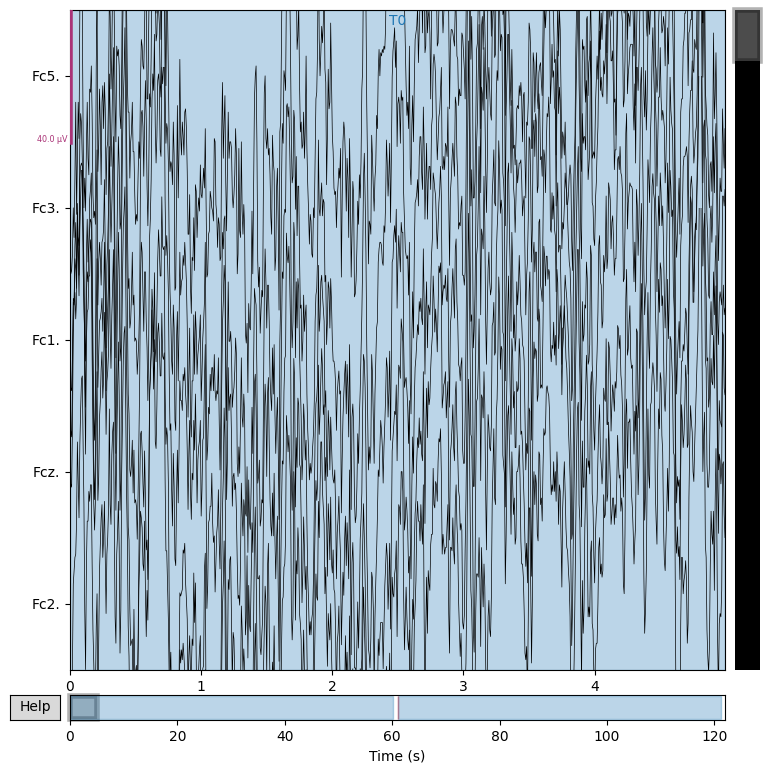

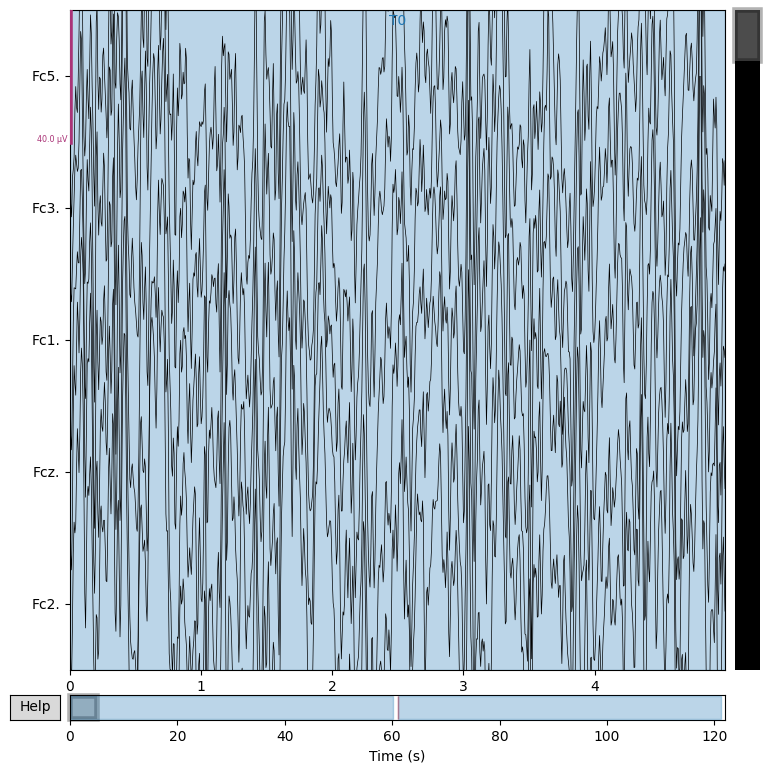

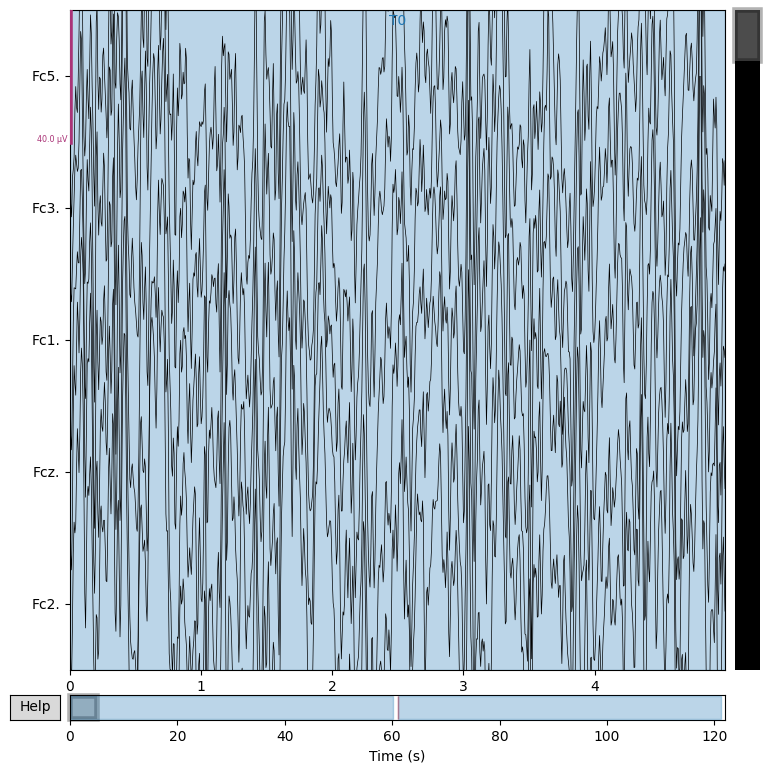

In [13]:
raw.plot(duration=5, n_channels=5, title="Raw EEG")
raw_filtered.plot(duration=5, n_channels=5, title="Filtered EEG (1–40 Hz)")

6. Extract Alpha Waves (8–12 Hz)

In [18]:
# Compute Power Spectral Density (frequency analysis of EEG signals)

psds, freqs = raw_filtered.compute_psd(
    method="welch",   # Welch method = standard in neuroscience
    fmin=1,           # ignore very slow drift
    fmax=40,          # ignore high-frequency noise
    n_fft=2048        # resolution of frequency breakdown
).get_data(return_freqs=True)

Effective window size : 12.800 (s)


In [19]:
# Create a mask that selects only alpha frequencies (8–12 Hz)
alpha_mask = (freqs >= 8) & (freqs <= 12)

# Extract only alpha-band power from all EEG channels
alpha_power = psds[:, alpha_mask].mean(axis=1)

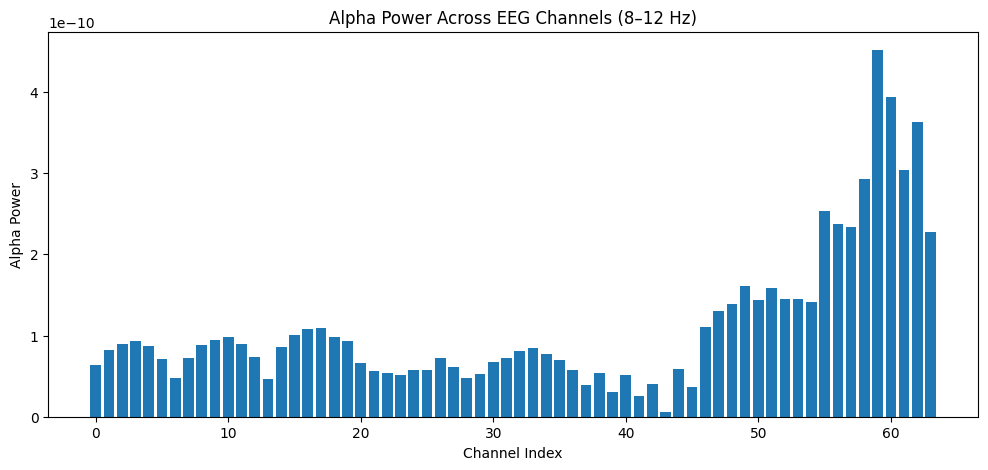

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot alpha power across channels
plt.bar(range(len(alpha_power)), alpha_power)

# Labels
plt.title("Alpha Power Across EEG Channels (8–12 Hz)")
plt.xlabel("Channel Index")
plt.ylabel("Alpha Power")

plt.show()

Scientific interpretation + project framing
The alpha band (8–12 Hz) was extracted from EEG recordings using frequency-domain analysis. The results show variation in alpha power across different EEG channels, suggesting spatial heterogeneity in cortical activity. Higher alpha power likely reflects regions in a more relaxed or idle state, consistent with established literature linking alpha oscillations to cortical inhibition and resting-state activity.